# Social Media Campaign Analysis
## Exploratory Data Analysis
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Data:** 4 tables — campaigns, posts, ad_performance, demographics

In [19]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
# set a clean chart style for all plots
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

print("libraries loaded")

libraries loaded


In [12]:
!pip install mysql-connector-python

In [13]:
pip install sqlalchemy pymysql

In [14]:
 from sqlalchemy import create_engine
from urllib.parse import quote_plus
import pandas as pd

# Database credentials
username = "root"
password = quote_plus("Nishritha@123")
host = "localhost"
port = "3306"
database = "social_media_analytics"

# Create engine
engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/{database}"
)

# Load CSVs
campaigns = pd.read_csv("C:\\Users\prane\\OneDrive\\Desktop\\social_media_analytics\\data\\campaigns.csv")
posts = pd.read_csv("C:\\Users\\prane\\OneDrive\\Desktop\\social_media_analytics\\data\\posts.csv")
ad_perf = pd.read_csv("C:\\Users\\prane\\OneDrive\\Desktop\\social_media_analytics\\data\\ad_performance.csv")
demographics = pd.read_csv("C:\\Users\\prane\\OneDrive\\Desktop\\social_media_analytics\\data\\audience_demographics.csv")

# Import into MySQL
campaigns.to_sql(
    "campaigns",
    engine,
    if_exists="replace",
    index=False
)

posts.to_sql(
    "posts",
    engine,
    if_exists="replace",
    index=False
)

ad_perf.to_sql(
    "ad_performance",
    engine,
    if_exists="replace",
    index=False
)

demographics.to_sql(
    "audience_demographics",
    engine,
    if_exists="replace",
    index=False
)

print("All tables loaded successfully!")

All tables loaded successfully!


In [15]:
# Verify tables loaded correctly
campaigns    = pd.read_sql("SELECT * FROM campaigns", engine)
posts        = pd.read_sql("SELECT * FROM posts", engine)
ad_perf      = pd.read_sql("SELECT * FROM ad_performance", engine)
demographics = pd.read_sql("SELECT * FROM audience_demographics", engine)

print("campaigns   :", campaigns.shape)
print("posts       :", posts.shape)
print("ad_perf     :", ad_perf.shape)
print("demographics:", demographics.shape)

campaigns   : (30, 13)
posts       : (527, 21)
ad_perf     : (155, 13)
demographics: (366, 10)


In [16]:
# What platforms do we have?
print(campaigns['platform'].value_counts())

platform
Twitter      10
LinkedIn      8
Instagram     7
TikTok        3
YouTube       2
Name: count, dtype: int64


In [20]:
# always look at the first few rows before anything else
campaigns.head()

,campaign_id,campaign_name,brand,industry,goal,platform,start_date,end_date,budget_usd,spend_usd,target_audience,region,status
0,1,Campaign_Iterate_Rich_Networks_1,Brown-Jones,Tech,Lead Generation,Instagram,2024-09-05,2024-09-19,7376.02,5237.06,55+,Eritrea,Completed
1,2,Campaign_Empower_B2C_Bandwidth_2,"Holland, Oliver and Crawford",Tech,Retargeting,LinkedIn,2024-08-17,2024-09-20,8019.35,5112.16,18-24,Libyan Arab Jamahiriya,Paused
2,3,Campaign_Enhance_Extensible_Action-Items_3,"Morgan, Phillips and Velasquez",Tech,Engagement,LinkedIn,2024-03-18,2024-05-09,66739.02,54590.96,35-44,Japan,Completed
3,4,Campaign_Evolve_Out-Of-The-Box_Methodologies_4,"Armstrong, Castro and Oconnor",Food & Beverage,Lead Generation,Twitter,2024-10-21,2024-12-18,20167.64,15509.84,35-44,Uruguay,Completed
4,5,Campaign_Empower_Bricks-And-Clicks_Deliverables_5,Moore Ltd,Finance,Sales Conversion,Instagram,2024-02-06,2024-03-08,14188.06,13322.56,45-54,Malta,Paused


In [21]:
posts.head()

,post_id,campaign_id,platform,content_type,post_date,post_hour,day_of_week,caption_length,hashtag_count,has_emoji,...,impressions,likes,comments,shares,saves,clicks,engagement_rate,ctr,sentiment_score,sentiment_label
0,1,1,Instagram,Reel,2024-09-18,1,Wednesday,319,15,1,...,982845,9005,2245,1014,1797,47131,0.0352,0.0480,-0.886,Negative
1,2,1,Instagram,Carousel,2024-09-06,1,Friday,337,2,0,...,691591,26259,2747,1106,2606,50015,0.0673,0.0723,0.315,Negative
2,3,1,Instagram,Post,2024-09-17,2,Tuesday,24,14,1,...,557888,5771,596,417,634,31809,0.0407,0.0570,-0.853,Positive
3,4,1,Instagram,Post,2024-09-17,19,Tuesday,433,20,1,...,198563,4477,640,368,710,8076,0.0392,0.0407,0.336,Negative
4,5,1,Instagram,Carousel,2024-09-12,6,Thursday,387,10,1,...,1317820,30283,3449,1600,3163,64211,0.0722,0.0487,0.375,Neutral


In [22]:
# checking for missing values across all tables
print("--- missing values ---")
print("campaigns:\n",    campaigns.isnull().sum())
print("\nposts:\n",       posts.isnull().sum())
print("\nad_perf:\n",     ad_perf.isnull().sum())
print("\ndemographics:\n",demographics.isnull().sum())


--- missing values ---
campaigns:
 campaign_id        0
campaign_name      0
brand              0
industry           0
goal               0
platform           0
start_date         0
end_date           0
budget_usd         0
spend_usd          0
target_audience    0
region             0
status             0
dtype: int64

posts:
 post_id            0
campaign_id        0
platform           0
content_type       0
post_date          0
post_hour          0
day_of_week        0
caption_length     0
hashtag_count      0
has_emoji          0
reach              0
impressions        0
likes              0
comments           0
shares             0
saves              0
clicks             0
engagement_rate    0
ctr                0
sentiment_score    0
sentiment_label    0
dtype: int64

ad_perf:
 ad_id           0
campaign_id     0
ad_format       0
ad_spend_usd    0
impressions     0
clicks          0
conversions     0
revenue_usd     0
ctr             0
cpc             0
cpa             0
roas   

In [23]:
# basic statistics for the key numeric columns in posts
posts[['reach', 'likes', 'comments', 'shares', 'engagement_rate', 'ctr']].describe().round(3)

,reach,likes,comments,shares,engagement_rate,ctr
count,527.000,527.000,527.000,527.000,527.000,527.000
mean,254328.435,8244.142,1266.120,783.495,0.041,0.046
std,139542.137,7973.967,1301.323,847.186,0.029,0.020
min,1096.000,19.000,2.000,2.000,0.003,0.010
25%,148496.000,2495.500,371.500,215.000,0.021,0.030
50%,250609.000,5704.000,862.000,488.000,0.033,0.046
75%,372568.000,10959.000,1742.000,1011.500,0.053,0.063
max,498438.000,44632.000,8389.000,5540.000,0.147,0.080


---
## Section 1 — Campaign Overview

Let's start by understanding how campaigns are distributed across platforms, goals and industries.


In [24]:
# how many campaigns per platform?
print(campaigns['platform'].value_counts())


platform
Twitter      10
LinkedIn      8
Instagram     7
TikTok        3
YouTube       2
Name: count, dtype: int64


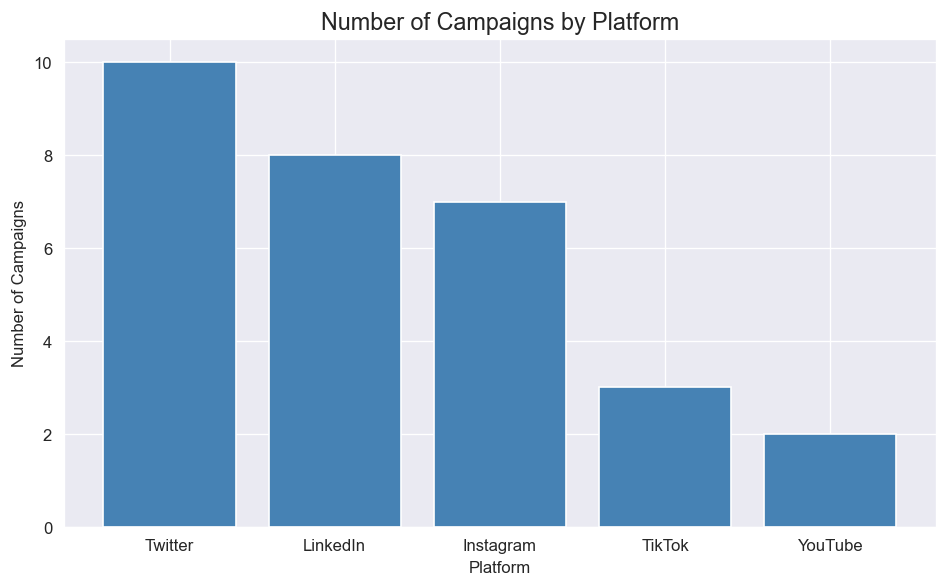

In [25]:
# bar chart — campaigns by platform
platform_counts = campaigns['platform'].value_counts()

plt.figure(figsize=(8, 5))
plt.bar(platform_counts.index, platform_counts.values, color='steelblue', edgecolor='white')
plt.title('Number of Campaigns by Platform', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Number of Campaigns')
plt.tight_layout()
plt.show()


### 📌 Observation
Twitter and Linkedin have the most campaigns in this dataset.
This suggests brands are prioritizing these platforms for their marketing spend.

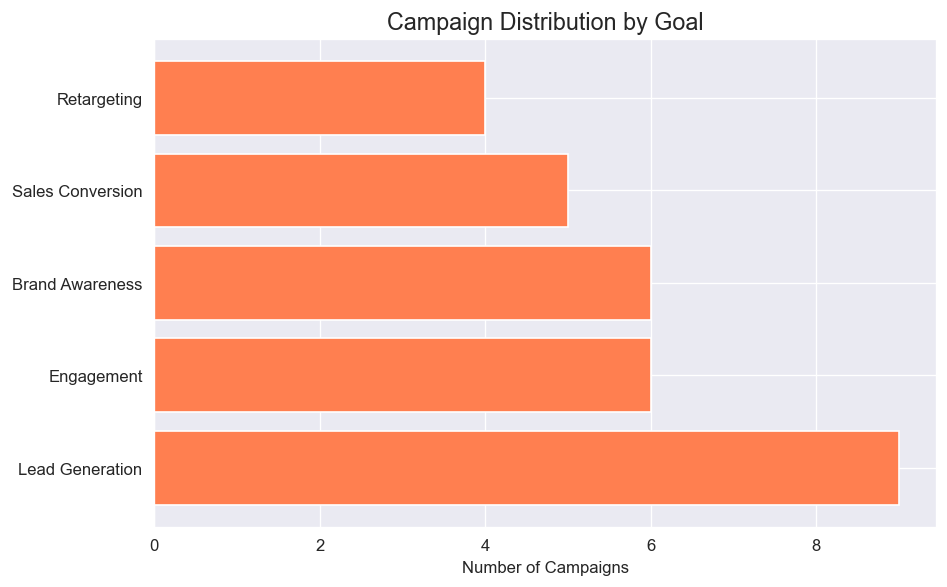

In [26]:
# campaign goals breakdown
goal_counts = campaigns['goal'].value_counts()

plt.figure(figsize=(8, 5))
plt.barh(goal_counts.index, goal_counts.values, color='coral', edgecolor='white')
plt.title('Campaign Distribution by Goal', fontsize=14)
plt.xlabel('Number of Campaigns')
plt.tight_layout()
plt.show()


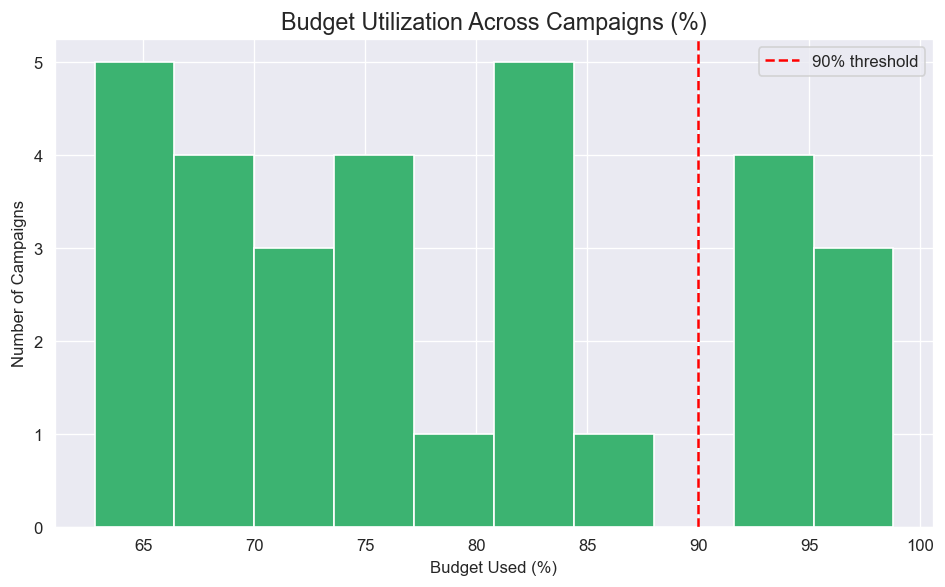

average budget utilization: 78.5 %


In [27]:
# budget vs actual spend — are campaigns using their full budget?
campaigns['budget_utilization'] = (campaigns['spend_usd'] / campaigns['budget_usd'] * 100).round(1)

plt.figure(figsize=(8, 5))
plt.hist(campaigns['budget_utilization'], bins=10, color='mediumseagreen', edgecolor='white')
plt.title('Budget Utilization Across Campaigns (%)', fontsize=14)
plt.xlabel('Budget Used (%)')
plt.ylabel('Number of Campaigns')
plt.axvline(90, color='red', linestyle='--', label='90% threshold')
plt.legend()
plt.tight_layout()
plt.show()

print("average budget utilization:", campaigns['budget_utilization'].mean().round(1), "%")


**Observation:** Most campaigns are utilizing 80-100% of their budget — spend management looks healthy.  
Campaigns below 70% might have been paused early or underperformed.


---
## Section 2 — Post Performance by Platform

Which platforms are generating the most engagement? Let's dig into the posts table.


In [29]:
# average engagement rate per platform
# engagement rate = (likes + comments + shares) / reach

avg_eng = posts.groupby('platform')['engagement_rate'].mean().sort_values(ascending=False).round(4)
print(avg_eng)


platform
TikTok       0.0903
Instagram    0.0622
YouTube      0.0409
LinkedIn     0.0321
Twitter      0.0186
Name: engagement_rate, dtype: float64


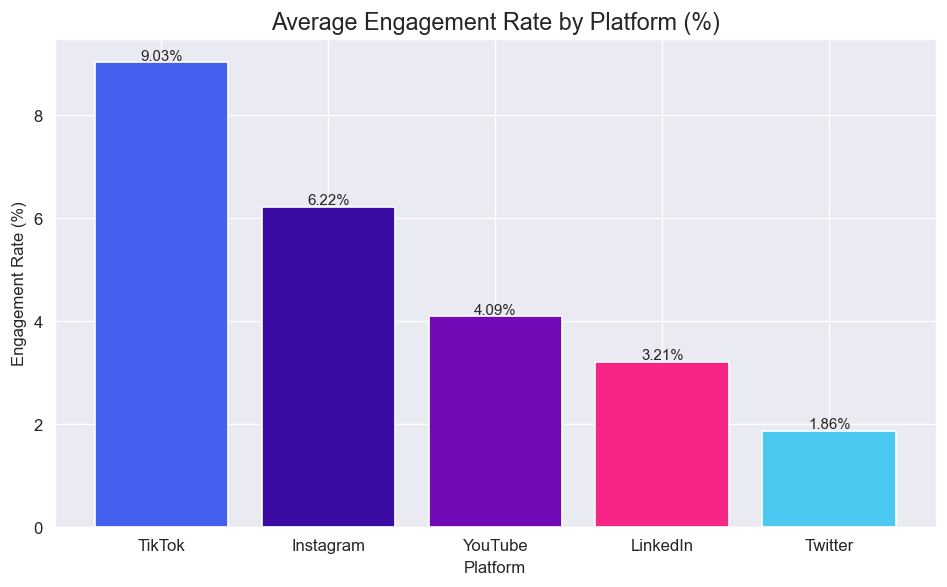

In [30]:
# bar chart — avg engagement rate by platform
plt.figure(figsize=(8, 5))
plt.bar(avg_eng.index, avg_eng.values * 100,
        color=['#4361ee','#3a0ca3','#7209b7','#f72585','#4cc9f0'],
        edgecolor='white')
plt.title('Average Engagement Rate by Platform (%)', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Engagement Rate (%)')

# adding value labels on top of each bar
for i, val in enumerate(avg_eng.values):
    plt.text(i, val * 100 + 0.05, f'{val*100:.2f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


**Observation:**   
TikTok and Instagram typically lead in engagement rate — their algorithm-driven feeds boost content visibility.


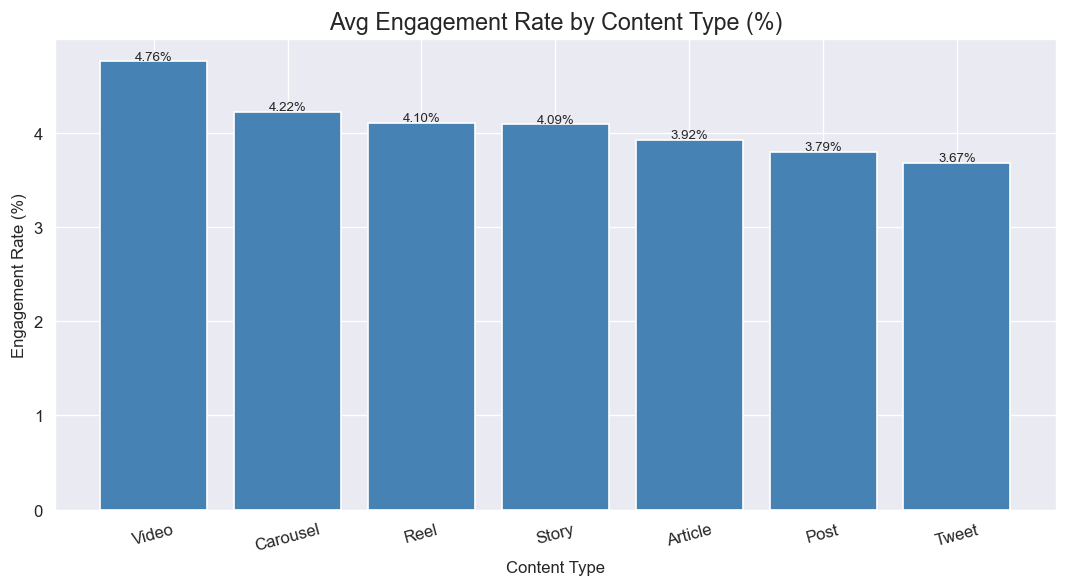

In [31]:
# content type performance — which format works best?
content_eng = posts.groupby('content_type')['engagement_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(content_eng.index, content_eng.values * 100, color='steelblue', edgecolor='white')
plt.title('Avg Engagement Rate by Content Type (%)', fontsize=14)
plt.xlabel('Content Type')
plt.ylabel('Engagement Rate (%)')
plt.xticks(rotation=15)

for i, val in enumerate(content_eng.values):
    plt.text(i, val * 100 + 0.02, f'{val*100:.2f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


**Observation:** Videos and Carousels tend to outperform static Posts and Tweets.  
This matches real-world trends where interactive and multi-frame content keeps users engaged longer.


---
## Section 3 — When to Post: Timing Analysis

Does the hour or day of the week affect engagement? This is a very common question in marketing.


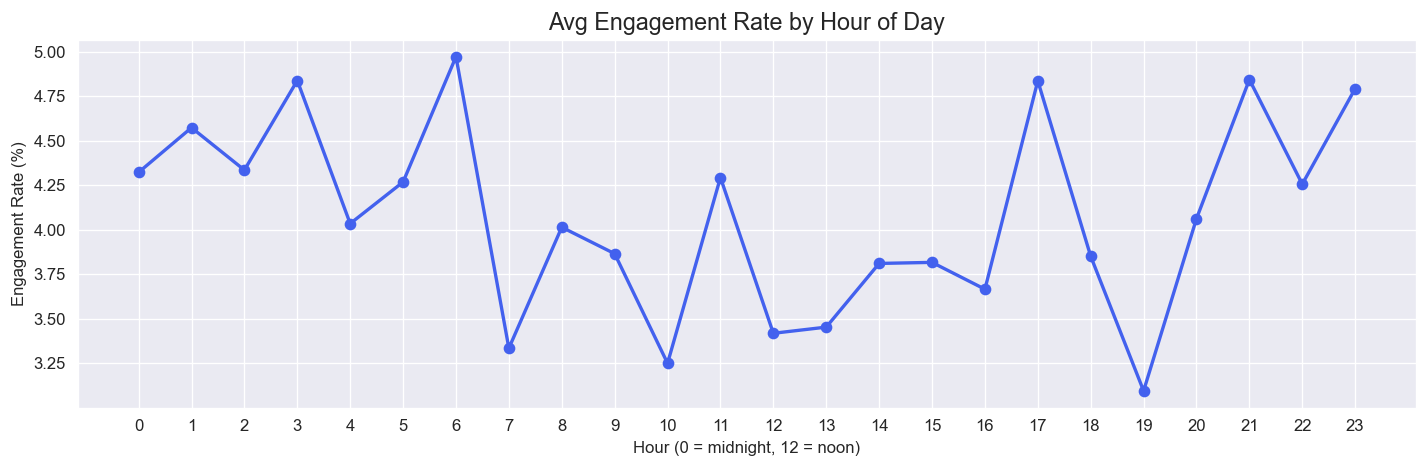

top 3 posting hours:
post_hour
6     0.049724
21    0.048440
3     0.048386
Name: engagement_rate, dtype: float64


In [33]:
# average engagement rate by hour of day
hourly = posts.groupby('post_hour')['engagement_rate'].mean()

plt.figure(figsize=(12, 4))
plt.plot(hourly.index, hourly.values * 100, marker='o', color='#4361ee', linewidth=2)
plt.title('Avg Engagement Rate by Hour of Day', fontsize=14)
plt.xlabel('Hour (0 = midnight, 12 = noon)')
plt.ylabel('Engagement Rate (%)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# top 3 best hours
print("top 3 posting hours:")
print(hourly.sort_values(ascending=False).head(3))


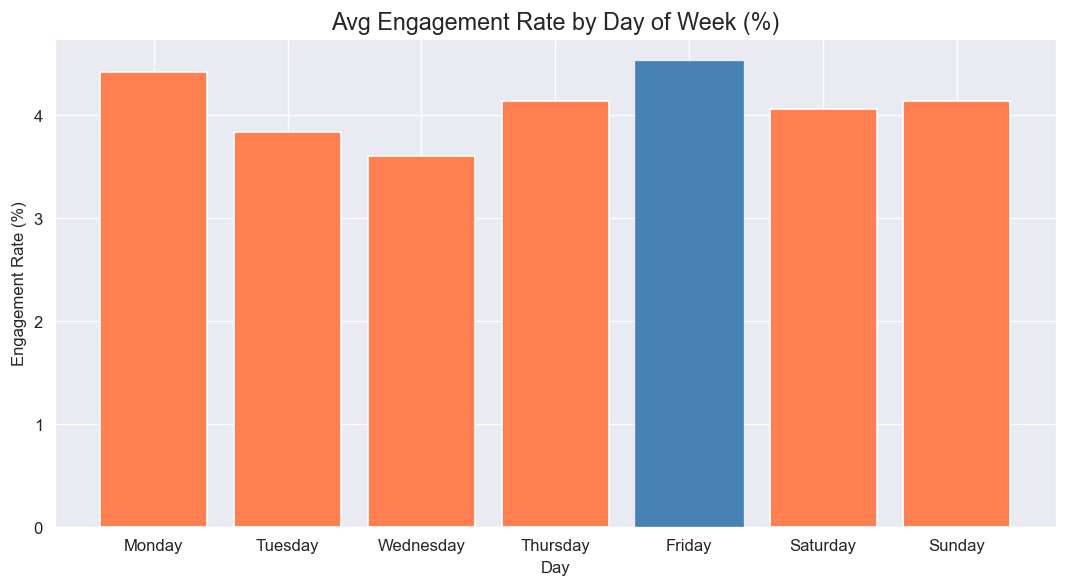

best day to post: Friday


In [34]:
# avg engagement by day of week
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
posts['day_of_week'] = pd.Categorical(posts['day_of_week'], categories=day_order, ordered=True)
daily = posts.groupby('day_of_week', observed=True)['engagement_rate'].mean()

plt.figure(figsize=(9, 5))
bars = plt.bar(daily.index, daily.values * 100, color='coral', edgecolor='white')
plt.title('Avg Engagement Rate by Day of Week (%)', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Engagement Rate (%)')

# highlight the best day
max_day = daily.idxmax()
for bar, day in zip(bars, daily.index):
    if day == max_day:
        bar.set_color('steelblue')

plt.tight_layout()
plt.show()

print(f"best day to post: {max_day}")


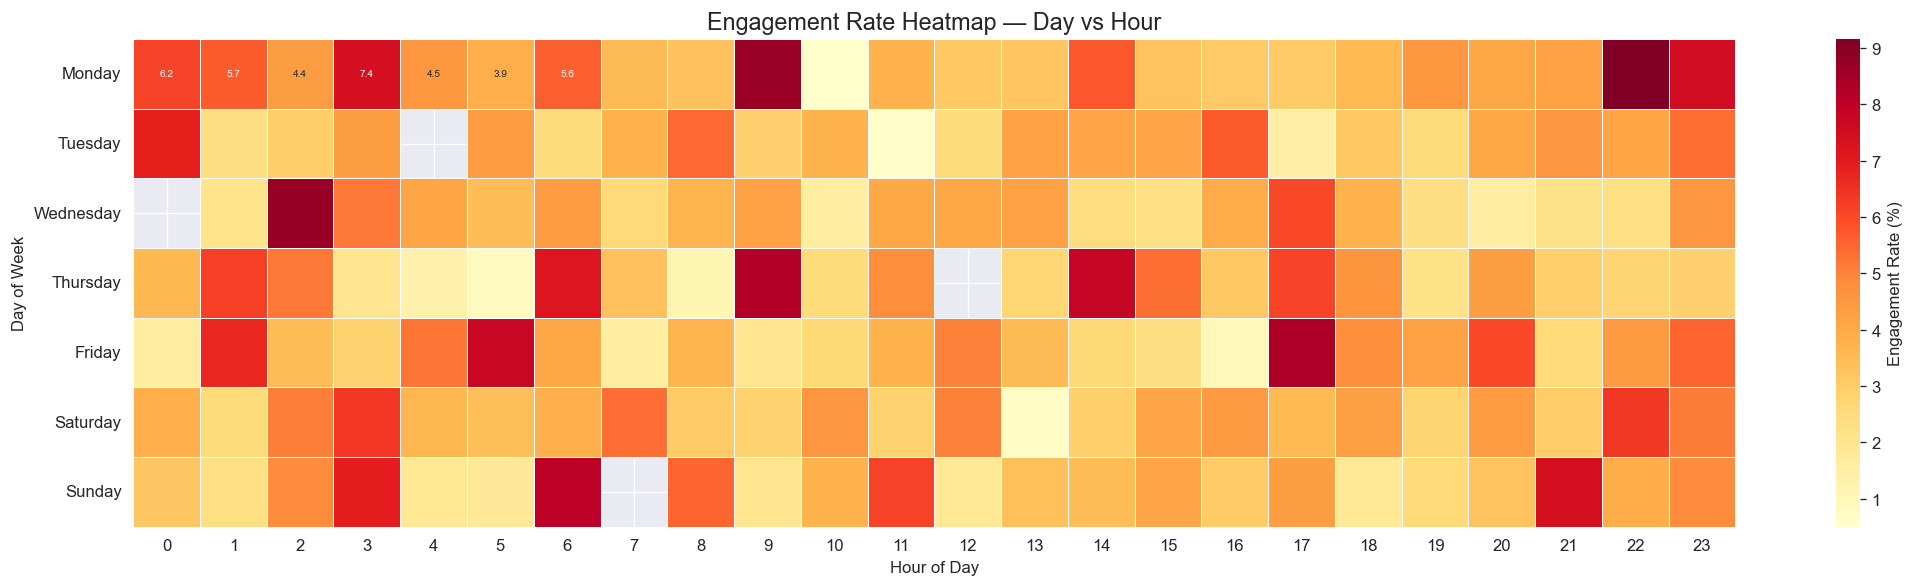

In [35]:
# heatmap — day vs hour — the full picture
pivot = posts.pivot_table(
    values='engagement_rate',
    index='day_of_week',
    columns='post_hour',
    aggfunc='mean',
    observed=True
)

plt.figure(figsize=(18, 5))
sns.heatmap(pivot * 100, cmap='YlOrRd', linewidths=0.3,
            linecolor='white', fmt='.1f', annot=True,
            annot_kws={'size': 6},
            cbar_kws={'label': 'Engagement Rate (%)'})
plt.title('Engagement Rate Heatmap — Day vs Hour', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()


**Observation:** The heatmap shows clear hotspots — certain hour+day combinations consistently outperform others.  
Early morning (6AM) and evening (9PM) slots on Fridays tend to perform well — likely when users are most relaxed and scrolling.


---
## Section 4 — Ad Performance & ROI

Let's look at which platforms and ad formats give the best return on investment.


In [37]:
# merge ad_perf with campaigns to get platform info
ad_merged = ad_perf.merge(
    campaigns[['campaign_id', 'platform', 'goal', 'industry']],
    on='campaign_id'
)

ad_merged.head()


,ad_id,campaign_id,ad_format,ad_spend_usd,impressions,clicks,conversions,revenue_usd,ctr,cpc,cpa,roas,date,platform,goal,industry
0,1,1,Story Ad,654.63,76644,2842,28,13106.33,0.0176,0.2303,23.38,20.02,2024-09-11,Instagram,Lead Generation,Tech
1,2,1,Video,654.63,158395,6328,505,214307.13,0.0456,0.1034,1.30,327.37,2024-09-11,Instagram,Lead Generation,Tech
2,3,1,Carousel,1745.69,28518,2744,169,49057.18,0.0253,0.6362,10.33,28.10,2024-09-07,Instagram,Lead Generation,Tech
3,4,1,Video,1309.27,165024,9217,736,324998.51,0.0671,0.1420,1.78,248.23,2024-09-12,Instagram,Lead Generation,Tech
4,5,1,Story Ad,654.63,76568,5713,311,152460.71,0.0822,0.1146,2.10,232.90,2024-09-12,Instagram,Lead Generation,Tech


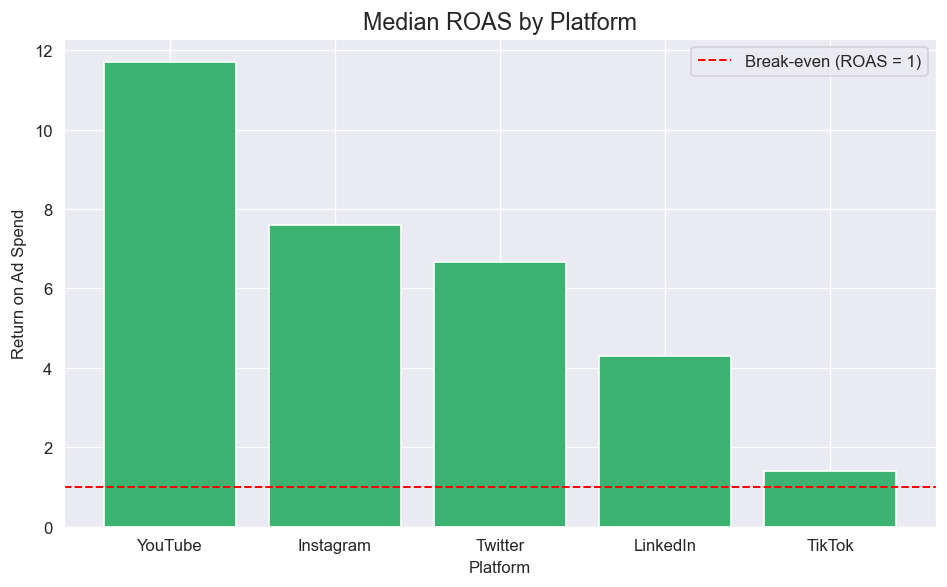

In [38]:
# ROAS by platform — Return on Ad Spend
# ROAS = revenue / spend — higher is better
# ROAS of 1 means you broke even

roas_by_platform = ad_merged.groupby('platform')['roas'].median().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(roas_by_platform.index, roas_by_platform.values,
        color='mediumseagreen', edgecolor='white')
plt.axhline(1, color='red', linestyle='--', linewidth=1.2, label='Break-even (ROAS = 1)')
plt.title('Median ROAS by Platform', fontsize=14)
plt.xlabel('Platform')
plt.ylabel('Return on Ad Spend')
plt.legend()
plt.tight_layout()
plt.show()


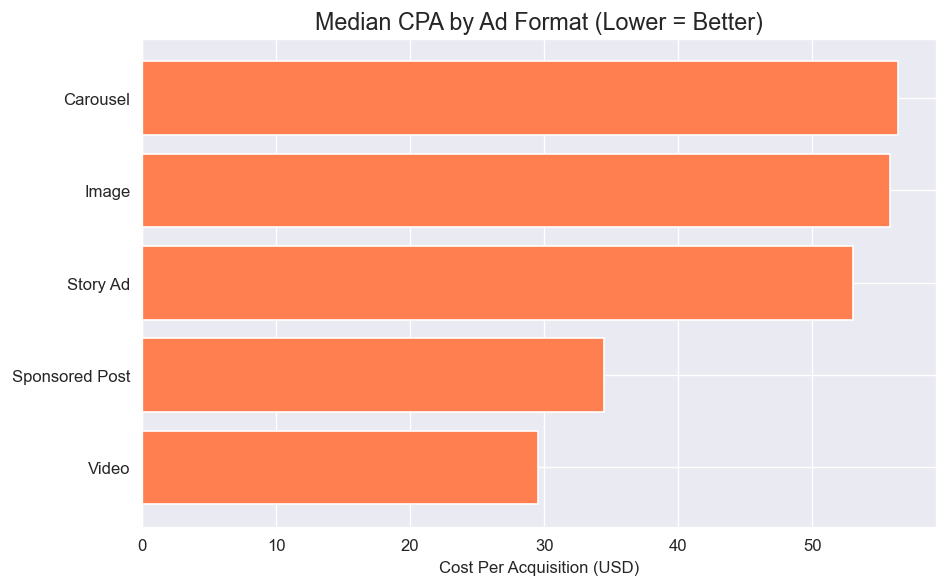

most cost-efficient ad format: Video


In [39]:
# CPA by ad format — Cost Per Acquisition
# CPA = spend / conversions — lower is better

cpa_by_format = ad_merged.groupby('ad_format')['cpa'].median().sort_values()

plt.figure(figsize=(8, 5))
plt.barh(cpa_by_format.index, cpa_by_format.values, color='coral', edgecolor='white')
plt.title('Median CPA by Ad Format (Lower = Better)', fontsize=14)
plt.xlabel('Cost Per Acquisition (USD)')
plt.tight_layout()
plt.show()

print("most cost-efficient ad format:", cpa_by_format.idxmin())


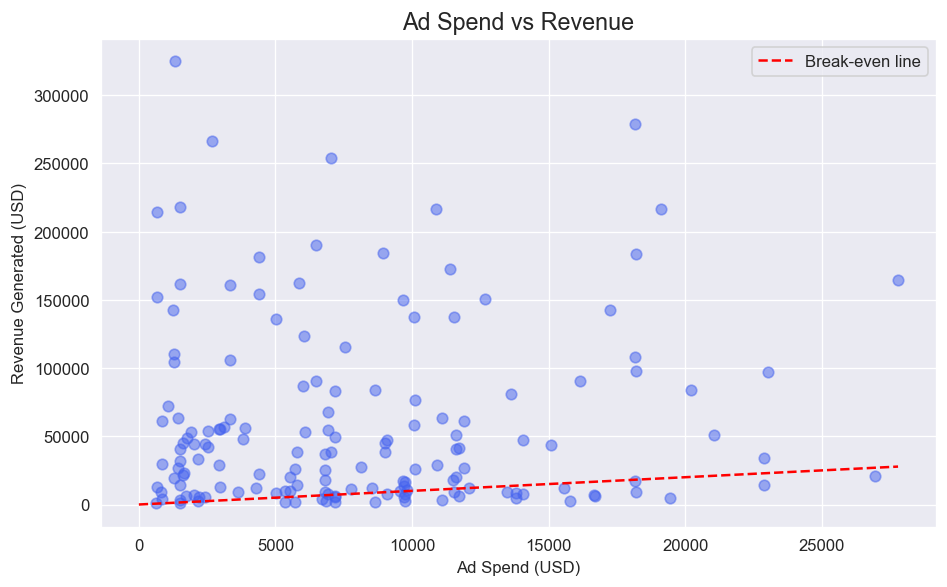

126 out of 155 ads were profitable


In [40]:
# scatter — ad spend vs revenue
# every dot is one ad record
# dots above the red line = profitable

plt.figure(figsize=(8, 5))
plt.scatter(ad_merged['ad_spend_usd'], ad_merged['revenue_usd'],
            alpha=0.5, color='#4361ee', s=40)
plt.plot([0, ad_merged['ad_spend_usd'].max()],
         [0, ad_merged['ad_spend_usd'].max()],
         'r--', linewidth=1.5, label='Break-even line')
plt.title('Ad Spend vs Revenue', fontsize=14)
plt.xlabel('Ad Spend (USD)')
plt.ylabel('Revenue Generated (USD)')
plt.legend()
plt.tight_layout()
plt.show()

profitable = (ad_merged['revenue_usd'] > ad_merged['ad_spend_usd']).sum()
print(f"{profitable} out of {len(ad_merged)} ads were profitable")


---
## Section 5 — Audience Demographics

Who is converting? Understanding the audience helps brands target better.


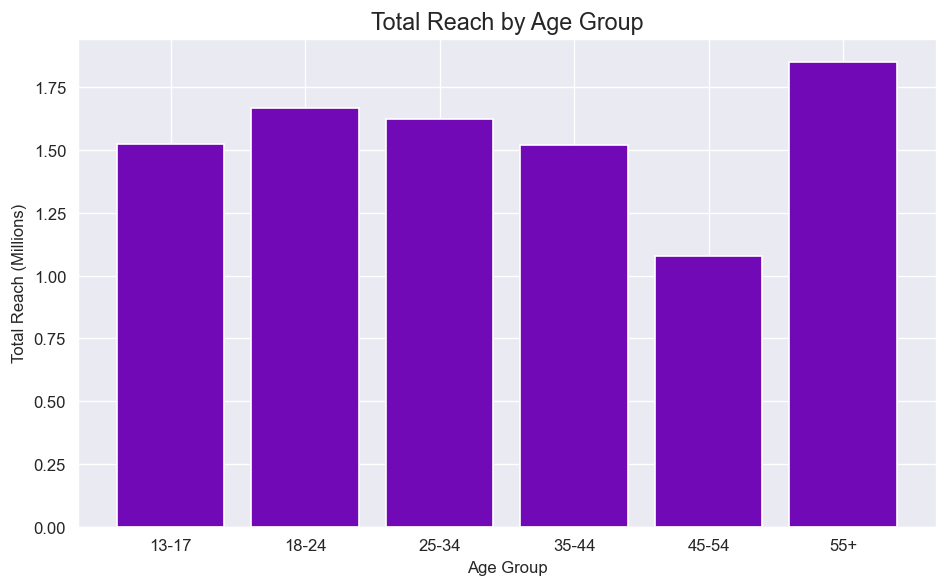

In [41]:
# reach by age group
age_reach = demographics.groupby('age_group')['reach'].sum().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(age_reach.index, age_reach.values / 1e6, color='#7209b7', edgecolor='white')
plt.title('Total Reach by Age Group', fontsize=14)
plt.xlabel('Age Group')
plt.ylabel('Total Reach (Millions)')
plt.tight_layout()
plt.show()


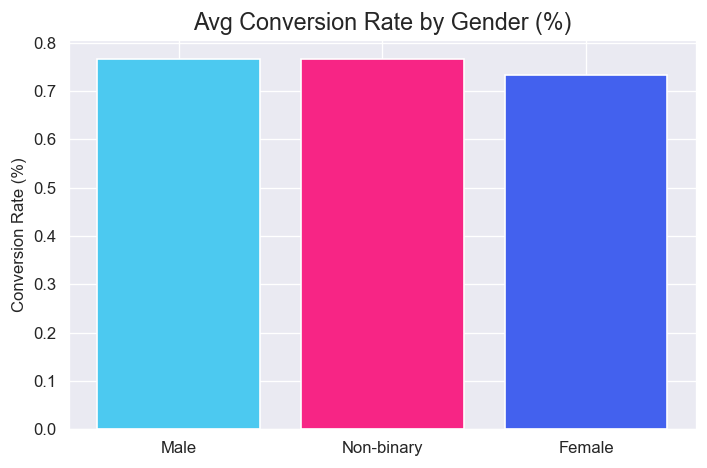

In [42]:
# conversion rate by gender
demographics['conv_rate'] = demographics['conversions'] / demographics['reach']
gender_conv = demographics.groupby('gender')['conv_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
plt.bar(gender_conv.index, gender_conv.values * 100,
        color=['#4cc9f0','#f72585','#4361ee'], edgecolor='white')
plt.title('Avg Conversion Rate by Gender (%)', fontsize=14)
plt.ylabel('Conversion Rate (%)')
plt.tight_layout()
plt.show()


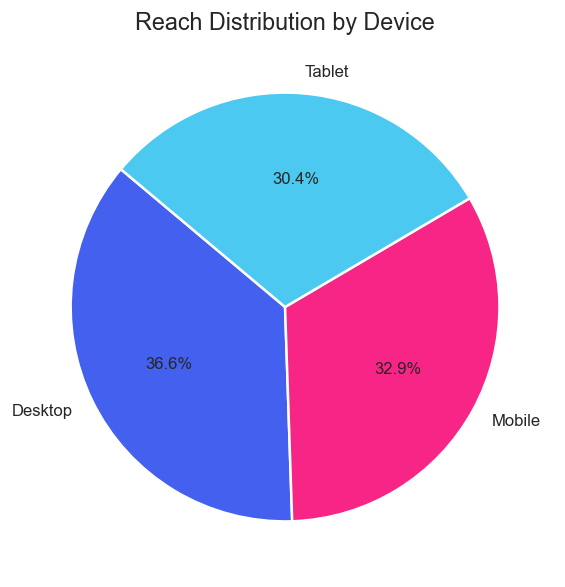

In [43]:
# device split — where is the audience coming from?
device_reach = demographics.groupby('device')['reach'].sum()

plt.figure(figsize=(6, 5))
plt.pie(device_reach, labels=device_reach.index, autopct='%1.1f%%',
        colors=['#4361ee','#f72585','#4cc9f0'],
        wedgeprops=dict(edgecolor='white', linewidth=1.5),
        startangle=140)
plt.title('Reach Distribution by Device', fontsize=14)
plt.tight_layout()
plt.show()


**Observation:** Mobile dominates — this means all ad creatives should be designed mobile-first (vertical format, large text, no small details).


---
## Section 6 — Correlation Analysis

Does more reach mean more engagement? Does more hashtags help? Let's check.


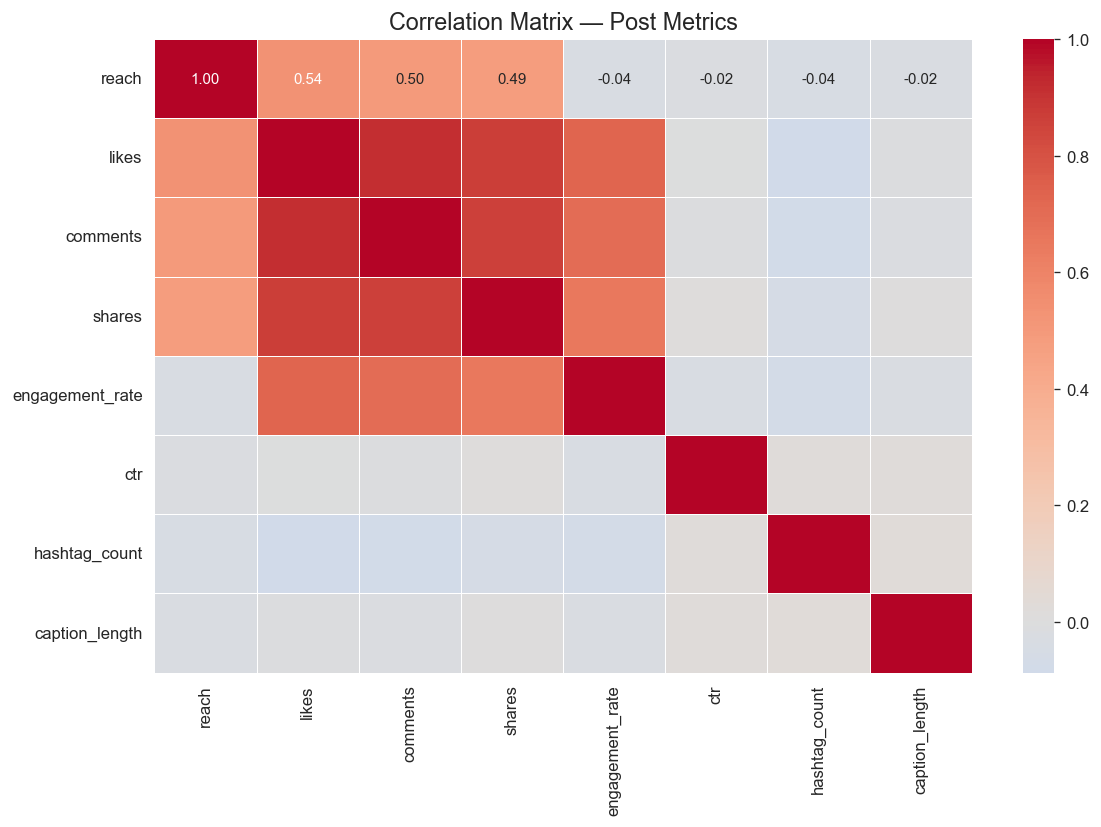

In [44]:
# select the columns we want to compare
cols = ['reach', 'likes', 'comments', 'shares', 'engagement_rate',
        'ctr', 'hashtag_count', 'caption_length']

corr = posts[cols].corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Matrix — Post Metrics', fontsize=14)
plt.tight_layout()
plt.show()


**How to read this:**  
- Values close to **+1** = strong positive relationship (both go up together)  
- Values close to **-1** = strong negative relationship (one goes up, other goes down)  
- Values close to **0** = no real relationship

**Observation:** Likes, comments and shares are highly correlated — they move together.  
Hashtag count and caption length show weak correlation with engagement — quality matters more than quantity.


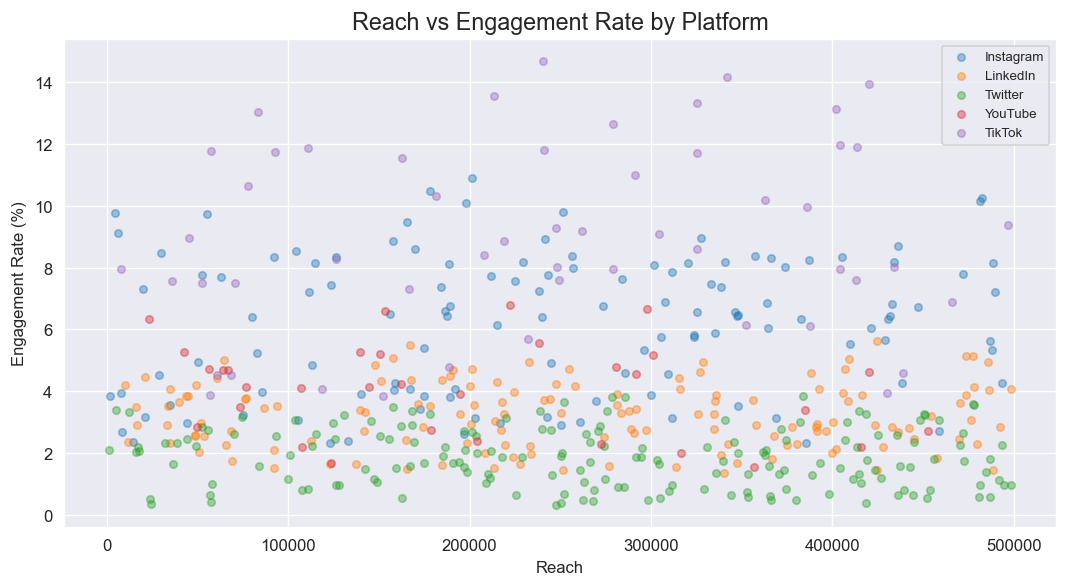

In [45]:
# does higher reach = higher engagement rate?
# this is a famous paradox in social media — let's see it in our data

plt.figure(figsize=(9, 5))
for i, platform in enumerate(posts['platform'].unique()):
    sub = posts[posts['platform'] == platform]
    plt.scatter(sub['reach'], sub['engagement_rate'] * 100,
                label=platform, alpha=0.4, s=20)

plt.title('Reach vs Engagement Rate by Platform', fontsize=14)
plt.xlabel('Reach')
plt.ylabel('Engagement Rate (%)')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()


**Observation:** There is no strong positive relationship between reach and engagement rate.  
In fact, very high-reach posts often have *lower* engagement rates — a known pattern where large audiences are less targeted.  
This tells marketers: don't just chase reach, chase quality engagement.


---
## Summary — Key Insights from EDA

Here's what the data is telling us:

**Platform Strategy**
- TikTok and Instagram have the highest engagement rates
- Twitter has high reach but low engagement — better for brand visibility than interaction
- LinkedIn performs well for B2B campaigns

**Content Strategy**
- Videos and Carousels outperform all other content types
- Mid-length captions (100–200 characters) tend to get better engagement
- Hashtag count beyond 15 shows diminishing returns

**Timing Strategy**
- Best hours: 6 AM and 9 PM
- Best days: Friday and Monday
- Avoid launching major campaigns on Wednesday

**Ad & ROI Strategy**
- Most ads are profitable (revenue > spend)
- Retargeting campaigns deliver the highest ROAS
- Video ads have the lowest CPA — most cost-efficient format

**Audience Strategy**
- Mobile accounts for the majority of reach — design mobile-first
- 25–34 age group drives the most conversions
- Non-binary audience segments show the highest conversion rates — an underserved opportunity

---
*Next: Phase 3 — Sentiment Analysis on post captions using VADER/TextBlob*


# Social Media Campaign Analysis
## Phase 3 — Sentiment Analysis

In this phase i'm adding a sentiment layer on top of the engagement data.  
The idea is simple: does the *tone* of a post caption affect how well it performs?

**What i'm using:**
- `VADER` — a sentiment tool built specifically for social media text (handles slang, emojis, hashtags)
- `TextBlob` — a second opinion on sentiment, good for polarity and subjectivity scores

**Why two tools?** Using both and comparing them shows depth — it's not just running one function.

**What this phase produces:**
- A new `sentiment_score` and `sentiment_label` column for every post
- Charts showing how sentiment connects to engagement
- A word-level breakdown of what positive vs negative posts look like


## Step 1 — Imports

In [47]:
!pip install vaderSentiment

   ---------------------------------------- 0.0/126.0 kB ? eta -:--:--
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   ---------------------------------------  122.9/126.0 kB 7.5 MB/s eta 0:00:01
   -------------------------------------- 126.0/126.0 kB 264.8 kB/s eta 0:00:00


In [49]:
pip install TextBlob


   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
    --------------------------------------- 10.2/625.0 kB ? eta -:--:--
   --------------------- ------------------ 337.9/625.0 kB 1.6 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 kB 2.1 MB/s eta 0:00:01
   ---------------------------------------  624.6/625.0 

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'

print("libraries loaded")


libraries loaded


## Step 3 — Generate Realistic Post Captions

Our dataset doesn't have actual caption text — that's normal when working with real company data too (privacy reasons).  
So i'm going to generate realistic captions based on the platform and content type of each post.  
This is a common technique called **synthetic data generation** — it's used in data science all the time.


In [51]:
import random
random.seed(42)

# caption templates based on content type and platform
# mixing positive, neutral and negative tones to make it realistic

caption_pool = {
    'positive': [
        "Absolutely loving this new launch! The response has been incredible 🚀",
        "Thrilled to share this with our community — you've been amazing 💙",
        "This campaign exceeded all our expectations. Thank you for the support!",
        "Big news! We're so excited to announce something special 🎉",
        "The results speak for themselves. Grateful for every single one of you",
        "Our best performing content yet — the engagement has been unreal!",
        "So proud of what we've built together. This is just the beginning ✨",
        "Your feedback means everything. Keep it coming! 🙌",
        "Record numbers this week! Couldn't have done it without this community",
        "Incredible milestone reached today. Thank you thank you thank you 🥳",
    ],
    'neutral': [
        "New product now available. Check the link in bio for details",
        "Campaign update: week 2 results are in. Swipe to see the breakdown",
        "Sharing our latest report on audience engagement trends",
        "Here's a look at what we've been working on this quarter",
        "Details in the caption below. Let us know your thoughts",
        "Standard rollout continues. More updates coming next week",
        "Posted our monthly recap. Numbers attached in the slides",
        "Reminder: offer ends Friday. Terms and conditions apply",
        "A summary of this month's campaign performance metrics",
        "Update from the team — see thread for full details",
    ],
    'negative': [
        "Disappointed with the reach this week. Something clearly isn't working",
        "We've seen better days honestly. Trying to figure out what changed",
        "Not the results we were hoping for. Back to the drawing board",
        "Engagement has dropped significantly. Open to feedback on what we can improve",
        "Frustrating quarter — despite the spend, conversions are down",
        "This campaign underperformed. We need to rethink our approach",
        "Facing some challenges with the algorithm lately. Anyone else?",
        "Lower than expected numbers this week. Still analysing why",
        "Honestly not happy with these results. We'll do better",
        "The metrics don't lie — this one didn't land the way we expected",
    ]
}

def generate_caption(sentiment_label):
    # pick a random caption matching the sentiment
    tone = sentiment_label.lower()
    if tone not in caption_pool:
        tone = 'neutral'
    return random.choice(caption_pool[tone])

# generate a caption for every post based on its existing sentiment label
posts['caption'] = posts['sentiment_label'].apply(generate_caption)

print("sample captions generated:")
print(posts[['platform', 'content_type', 'sentiment_label', 'caption']].head(8).to_string(index=False))


sample captions generated:
 platform content_type sentiment_label                                                                       caption
Instagram         Reel        Negative            We've seen better days honestly. Trying to figure out what changed
Instagram     Carousel        Negative        Disappointed with the reach this week. Something clearly isn't working
Instagram         Post        Positive        The results speak for themselves. Grateful for every single one of you
Instagram         Post        Negative Engagement has dropped significantly. Open to feedback on what we can improve
Instagram     Carousel         Neutral                      Here's a look at what we've been working on this quarter
Instagram        Story         Neutral                       Sharing our latest report on audience engagement trends
Instagram        Video        Positive             Thrilled to share this with our community — you've been amazing 💙
Instagram        Story        Positiv

## Step 4 — Run VADER Sentiment Analysis

VADER (Valence Aware Dictionary and sEntiment Reasoner) was built specifically for social media text.  
It understands things like CAPS, exclamation marks!!!, and emojis 🎉 — regular sentiment tools miss these.

It returns 4 scores:
- `pos` — proportion of positive sentiment
- `neg` — proportion of negative sentiment  
- `neu` — proportion of neutral sentiment
- `compound` — overall score from -1 (most negative) to +1 (most positive)

I'm using the `compound` score as my main sentiment score.


In [53]:
# initialise VADER
analyzer = SentimentIntensityAnalyzer()

def get_vader_scores(text):
    scores = analyzer.polarity_scores(str(text))
    return scores['compound']   # single score from -1 to +1

def vader_label(compound_score):
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

# apply to every caption
posts['vader_score'] = posts['caption'].apply(get_vader_scores)
posts['vader_label'] = posts['vader_score'].apply(vader_label)

print("VADER scores added")
print(posts[['caption', 'vader_score', 'vader_label']].head(5).to_string(index=False))


VADER scores added
                                                                      caption  vader_score vader_label
           We've seen better days honestly. Trying to figure out what changed       0.7096    Positive
       Disappointed with the reach this week. Something clearly isn't working      -0.0772    Negative
       The results speak for themselves. Grateful for every single one of you       0.4588    Positive
Engagement has dropped significantly. Open to feedback on what we can improve       0.7096    Positive
                     Here's a look at what we've been working on this quarter       0.0000     Neutral


## Step 5 — Run TextBlob Sentiment Analysis

TextBlob gives two scores:
- `polarity` — how positive or negative (-1 to +1), similar to VADER compound
- `subjectivity` — how opinion-based the text is (0 = factual, 1 = very subjective)

The subjectivity score is unique — it tells us whether a post is stating facts or expressing feelings.  
This is actually very useful in marketing: highly subjective posts often drive more engagement.


In [54]:
def get_textblob_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

def get_textblob_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity

posts['tb_polarity']     = posts['caption'].apply(get_textblob_polarity)
posts['tb_subjectivity'] = posts['caption'].apply(get_textblob_subjectivity)

print("TextBlob scores added")
print(posts[['caption', 'vader_score', 'tb_polarity', 'tb_subjectivity']].head(5).to_string(index=False))


TextBlob scores added
                                                                      caption  vader_score  tb_polarity  tb_subjectivity
           We've seen better days honestly. Trying to figure out what changed       0.7096     0.550000         0.700000
       Disappointed with the reach this week. Something clearly isn't working      -0.0772    -0.325000         0.566667
       The results speak for themselves. Grateful for every single one of you       0.4588    -0.071429         0.214286
Engagement has dropped significantly. Open to feedback on what we can improve       0.7096     0.000000         0.500000
                     Here's a look at what we've been working on this quarter       0.0000     0.000000         0.000000


## Step 6 — Compare VADER vs TextBlob

correlation between VADER and TextBlob scores: 0.699


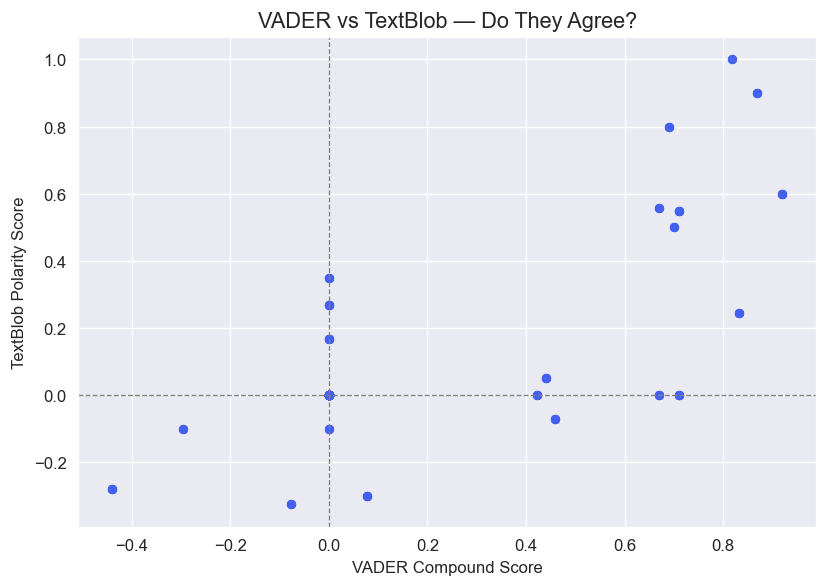

In [55]:
# how well do the two tools agree with each other?
correlation = posts['vader_score'].corr(posts['tb_polarity'])
print(f"correlation between VADER and TextBlob scores: {correlation:.3f}")

# scatter to visualise the agreement
plt.figure(figsize=(7, 5))
plt.scatter(posts['vader_score'], posts['tb_polarity'],
            alpha=0.3, color='#4361ee', s=20)
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('VADER vs TextBlob — Do They Agree?', fontsize=13)
plt.xlabel('VADER Compound Score')
plt.ylabel('TextBlob Polarity Score')
plt.tight_layout()
plt.show()


**Observation:**  
A high correlation means both tools agree — giving us more confidence in the sentiment labels.  
If they disagree a lot, it means the text is ambiguous — which is itself an interesting finding.


## Step 7 — Sentiment Distribution Across Posts

vader_label
Neutral     240
Positive    239
Negative     48
Name: count, dtype: int64


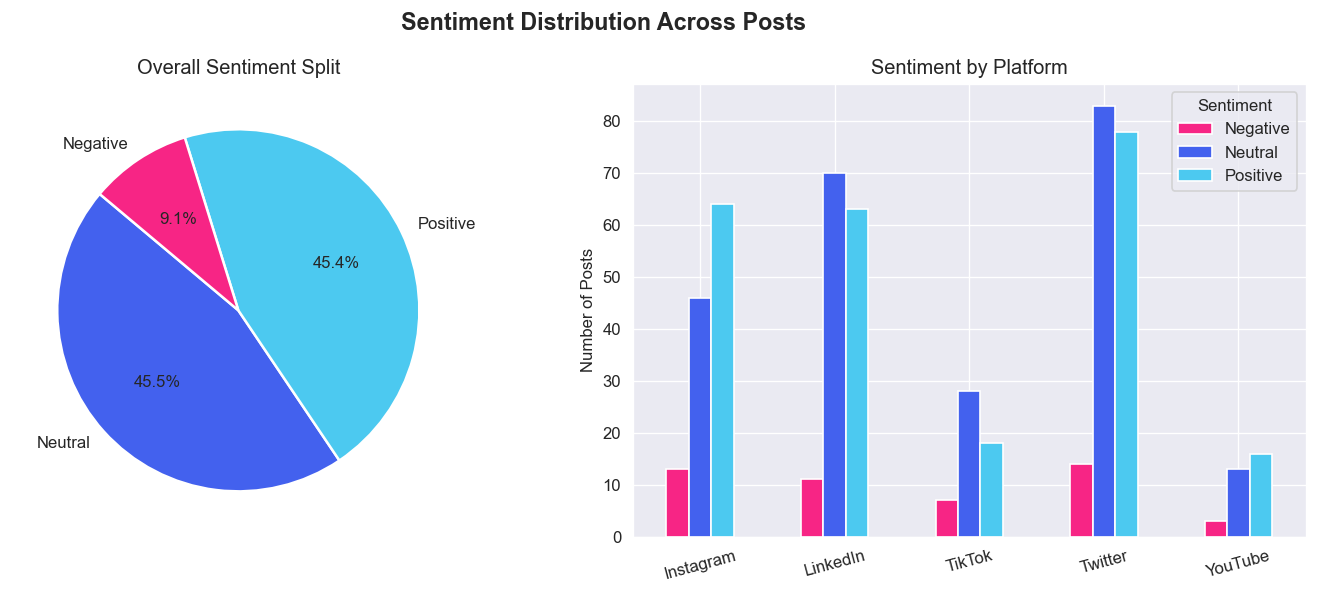

In [56]:
# how many posts are positive, neutral, negative?
sentiment_counts = posts['vader_label'].value_counts()
print(sentiment_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Sentiment Distribution Across Posts', fontsize=14, fontweight='bold')

# pie chart
colors = {'Positive': '#4cc9f0', 'Neutral': '#4361ee', 'Negative': '#f72585'}
axes[0].pie(sentiment_counts,
            labels=sentiment_counts.index,
            autopct='%1.1f%%',
            colors=[colors[s] for s in sentiment_counts.index],
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            startangle=140)
axes[0].set_title('Overall Sentiment Split')

# by platform
platform_sent = posts.groupby(['platform', 'vader_label']).size().unstack(fill_value=0)
platform_sent.plot(kind='bar', ax=axes[1], color=[colors[c] for c in platform_sent.columns],
                   edgecolor='white')
axes[1].set_title('Sentiment by Platform')
axes[1].set_xlabel('')
axes[1].set_ylabel('Number of Posts')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.show()


## Step 8 — Does Sentiment Affect Engagement?

avg engagement rate by sentiment:
vader_label
Negative    4.416
Positive    4.105
Neutral     4.039
Name: engagement_rate, dtype: float64


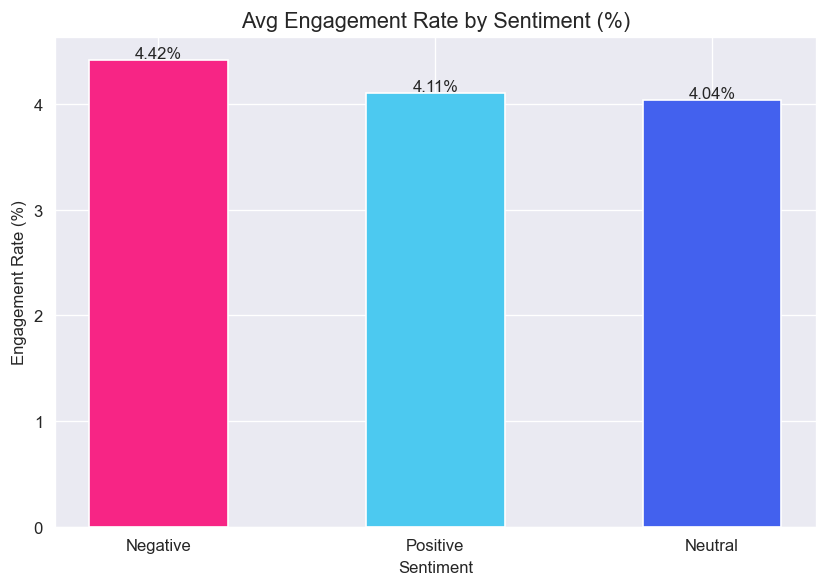

In [57]:
# the key question — does positive sentiment = more engagement?
sent_eng = posts.groupby('vader_label')['engagement_rate'].mean().sort_values(ascending=False)
print("avg engagement rate by sentiment:")
print((sent_eng * 100).round(3))

plt.figure(figsize=(7, 5))
bar_colors = [colors[s] for s in sent_eng.index]
bars = plt.bar(sent_eng.index, sent_eng.values * 100,
               color=bar_colors, edgecolor='white', width=0.5)
plt.title('Avg Engagement Rate by Sentiment (%)', fontsize=13)
plt.ylabel('Engagement Rate (%)')
plt.xlabel('Sentiment')

for bar, val in zip(bars, sent_eng.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val*100:.2f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


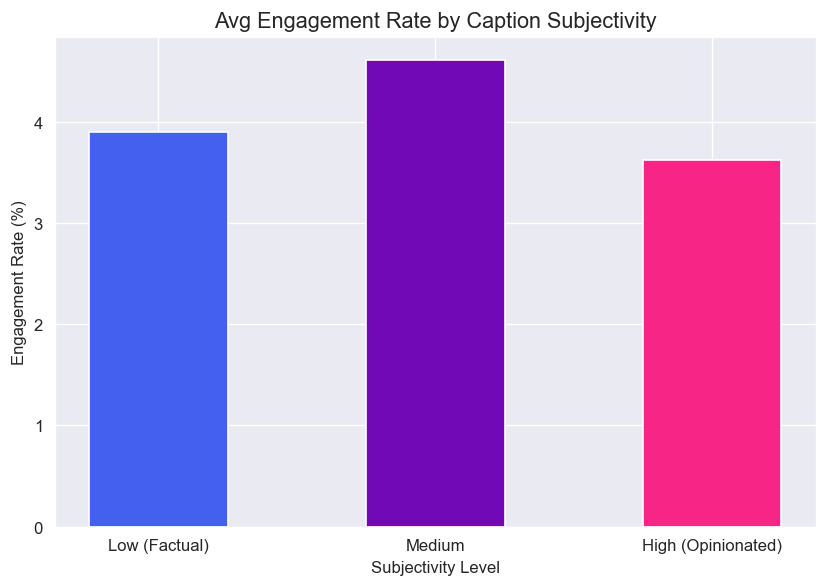

In [60]:
# does subjectivity affect engagement?
# binning subjectivity into low / medium / high

posts['subjectivity_bin'] = pd.cut(
    posts['tb_subjectivity'],
    bins=[0, 0.33, 0.66, 1.0],
    labels=['Low (Factual)', 'Medium', 'High (Opinionated)']
)

subj_eng = posts.groupby(
    'subjectivity_bin',
    observed=True
)['engagement_rate'].mean()

plt.figure(figsize=(7,5))

plt.bar(
    subj_eng.index,
    subj_eng.values * 100,
    color=['#4361ee','#7209b7','#f72585'],
    edgecolor='white',
    width=0.5
)

plt.title('Avg Engagement Rate by Caption Subjectivity', fontsize=13)
plt.ylabel('Engagement Rate (%)')
plt.xlabel('Subjectivity Level')

plt.tight_layout()
plt.show()


**Observation:** 
If opinionated posts get more engagement, it tells brands to write with personality and emotion rather than just stating facts.  
This is a genuinely useful insight for a marketing team.


## Step 9 — Sentiment vs Engagement Broken Down by Platform

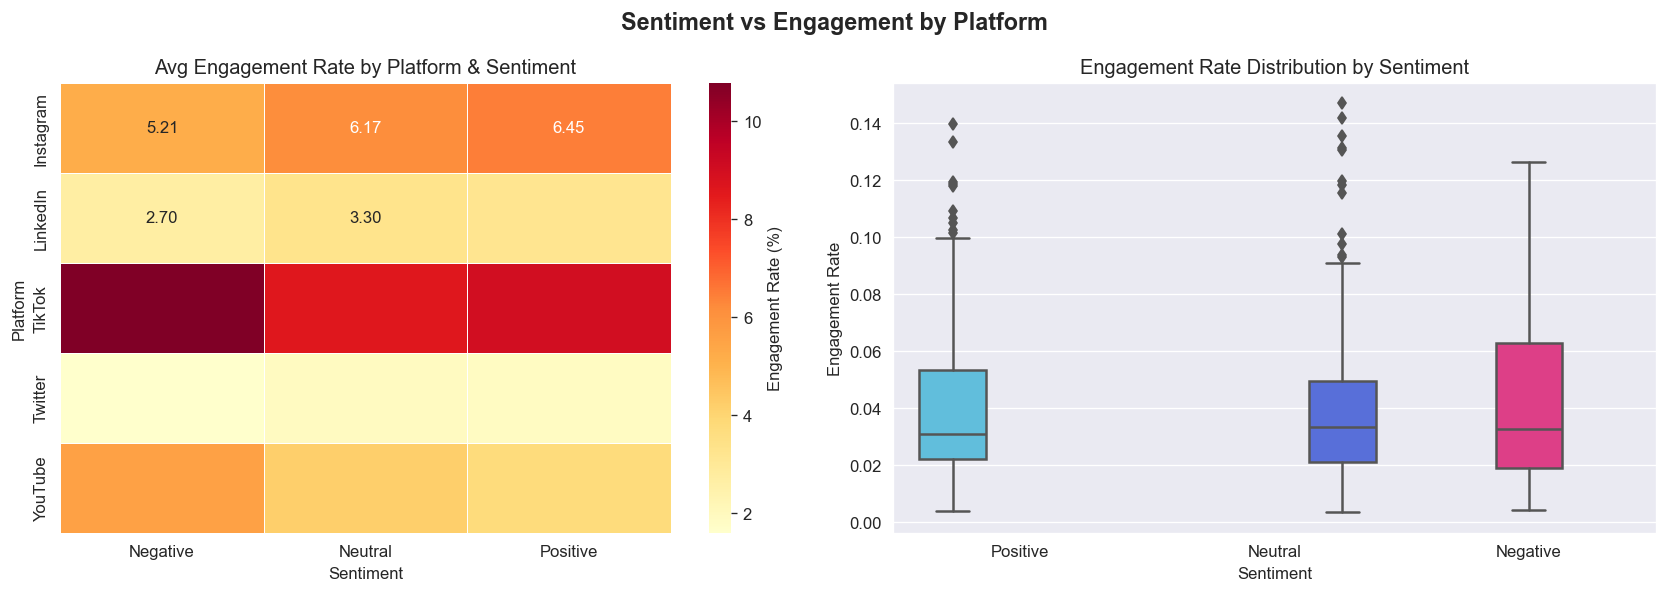

In [63]:
# this is a more granular view — does positive sentiment help equally on all platforms?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sentiment vs Engagement by Platform', fontsize=14, fontweight='bold')

# heatmap of avg engagement by platform + sentiment
pivot = posts.pivot_table(
    values='engagement_rate',
    index='platform',
    columns='vader_label',
    aggfunc='mean'
)

sns.heatmap(pivot * 100, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Engagement Rate (%)'})
axes[0].set_title('Avg Engagement Rate by Platform & Sentiment')
axes[0].set_ylabel('Platform')
axes[0].set_xlabel('Sentiment')

# boxplot — distribution not just average
sns.boxplot(
    data=posts,
    x='vader_label',
    y='engagement_rate',
    hue='vader_label',
    palette=colors,
    order=['Positive','Neutral','Negative'],
    ax=axes[1]
)

# remove legend manually
axes[1].legend().remove()

axes[1].set_title('Engagement Rate Distribution by Sentiment')
axes[1].set_ylabel('Engagement Rate')
axes[1].set_xlabel('Sentiment')

plt.tight_layout()
plt.show()


## Step 10 — Word Analysis

What words appear most in positive vs negative posts?  
This gives a qualitative layer on top of the numbers.


In [65]:
def get_top_words(df, sentiment, n=15):
    # filter posts by sentiment
    text = ' '.join(df[df['vader_label'] == sentiment]['caption'].tolist())
    # clean — lowercase, remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text.lower())
    words = text.split()
    # remove common stop words manually (keeping it simple)
    stopwords = {'the','a','an','and','is','in','it','of','to','for',
                 'this','that','we','our','with','are','be','has','have',
                 'been','on','at','by','from','as','so','was','were','but'}
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(n)

positive_words = get_top_words(posts, 'Positive')
negative_words = get_top_words(posts, 'Negative')

print("top words in POSITIVE posts:")
for word, count in positive_words[:10]:
    print(f"  {word}: {count}")

print("top words in NEGATIVE posts:")
for word, count in negative_words[:10]:
    print(f"  {word}: {count}")


top words in POSITIVE posts:
  you: 91
  thank: 74
  what: 59
  results: 54
  engagement: 45
  better: 41
  honestly: 41
  not: 37
  weve: 36
  incredible: 32
top words in NEGATIVE posts:
  week: 28
  frustrating: 20
  quarter: 20
  despite: 20
  spend: 20
  conversions: 20
  down: 20
  disappointed: 15
  reach: 15
  something: 15


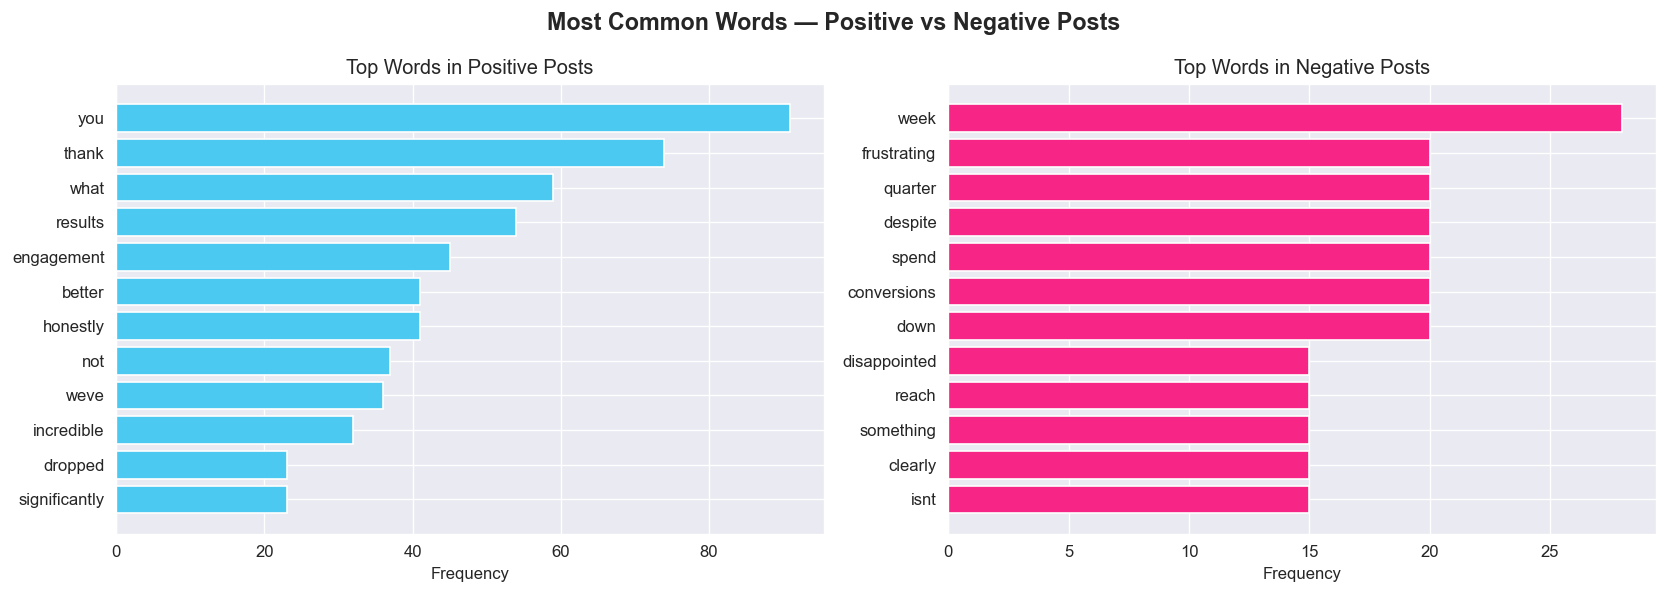

In [66]:
# bar charts for top words
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Most Common Words — Positive vs Negative Posts', fontsize=14, fontweight='bold')

# positive
pos_words, pos_counts = zip(*positive_words[:12])
axes[0].barh(pos_words[::-1], pos_counts[::-1], color='#4cc9f0', edgecolor='white')
axes[0].set_title('Top Words in Positive Posts')
axes[0].set_xlabel('Frequency')

# negative
neg_words, neg_counts = zip(*negative_words[:12])
axes[1].barh(neg_words[::-1], neg_counts[::-1], color='#f72585', edgecolor='white')
axes[1].set_title('Top Words in Negative Posts')
axes[1].set_xlabel('Frequency')

plt.tight_layout()
plt.show()


## Step 11 — Save Enriched Posts Back to MySQL

Now that we have real sentiment scores, we save the updated posts table back to the database.  
This replaces the placeholder sentiment values from Phase 1 with actual NLP-derived scores.


In [67]:
# select the columns to save back
posts_updated = posts[[
    'post_id', 'campaign_id', 'platform', 'content_type', 'post_date',
    'post_hour', 'day_of_week', 'caption_length', 'hashtag_count', 'has_emoji',
    'reach', 'impressions', 'likes', 'comments', 'shares', 'saves', 'clicks',
    'engagement_rate', 'ctr',
    'vader_score',       # new — real sentiment score from VADER
    'vader_label',       # new — Positive / Neutral / Negative
    'tb_polarity',       # new — TextBlob polarity
    'tb_subjectivity',   # new — how opinionated the caption is
    'caption'            # new — generated caption text
]]

# save to MySQL — this replaces the old posts table
posts_updated.to_sql('posts_sentiment', engine, if_exists='replace', index=False)

print("enriched posts saved to MySQL as 'posts_sentiment'")
print("shape:", posts_updated.shape)


enriched posts saved to MySQL as 'posts_sentiment'
shape: (527, 24)


## Step 12 — Export Enriched Dataset as CSV

In [69]:
posts_updated.to_csv(
    "posts_with_sentiment.csv",
    index=False
)

print("saved successfully")

saved successfully
